In [16]:
import numpy as np
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error, accuracy_score
from icecream import ic
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score, GridSearchCV
from tqdm import tqdm

## First try

In [17]:
df = pd.read_csv("cardio_regression.csv")
X = df.drop(columns=['cardio'])
Y = df['cardio']
X.shape, Y.shape


((68562, 12), (68562,))

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((54849, 12), (13713, 12), (54849,), (13713,))

In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy :", round(accuracy, 4))

y_pred = model.predict(X_test)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7267

Rapport de classification :
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6901
           1       0.76      0.66      0.71      6812

    accuracy                           0.73     13713
   macro avg       0.73      0.73      0.73     13713
weighted avg       0.73      0.73      0.73     13713

Matrice de confusion :
[[5451 1450]
 [2298 4514]]


## Deuxième démarche

Nous allons voir les classes qui impactes le plus la prédiction.

In [20]:
def make_regression(X):
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
    model = LogisticRegression()
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    y_pred = model.predict(X_test)
    print("Accuracy :", round(accuracy, 4))
    matrix = classification_report(y_test, y_pred)
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    return matrix

- Facteurs non modifiables

In [21]:
print(make_regression(df[['age', 'gender_female', 'gender_male']]))

Accuracy : 0.5982
Matrice de confusion :
[[3994 2907]
 [2603 4209]]
              precision    recall  f1-score   support

           0       0.61      0.58      0.59      6901
           1       0.59      0.62      0.60      6812

    accuracy                           0.60     13713
   macro avg       0.60      0.60      0.60     13713
weighted avg       0.60      0.60      0.60     13713



- Facteurs liés au mode de vie

In [22]:
print(make_regression(df[['smoke', 'alco', 'active']]))

Accuracy : 0.5121
Matrice de confusion :
[[5611 1290]
 [5400 1412]]
              precision    recall  f1-score   support

           0       0.51      0.81      0.63      6901
           1       0.52      0.21      0.30      6812

    accuracy                           0.51     13713
   macro avg       0.52      0.51      0.46     13713
weighted avg       0.52      0.51      0.46     13713



- Facteurs cliniques en amont

In [23]:
print(make_regression(df[['weight', 'height']]))

Accuracy : 0.5821
Matrice de confusion :
[[4671 2230]
 [3501 3311]]
              precision    recall  f1-score   support

           0       0.57      0.68      0.62      6901
           1       0.60      0.49      0.54      6812

    accuracy                           0.58     13713
   macro avg       0.58      0.58      0.58     13713
weighted avg       0.58      0.58      0.58     13713



- Facteurs cliniques en aval

In [24]:
print(make_regression(df[['ap_hi', 'ap_lo', 'cholesterol', 'gluc']]))

Accuracy : 0.7211
Matrice de confusion :
[[5513 1388]
 [2437 4375]]
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      6901
           1       0.76      0.64      0.70      6812

    accuracy                           0.72     13713
   macro avg       0.73      0.72      0.72     13713
weighted avg       0.73      0.72      0.72     13713



## Troisième démarche

Ajout des features : bmi, pulse_pressure, is_hypertensive

In [25]:
df = pd.read_csv("cardio_new_features.csv")
X = df.drop(columns=['cardio'])
Y = df['cardio']
X.shape, Y.shape


((68562, 13), (68562,))

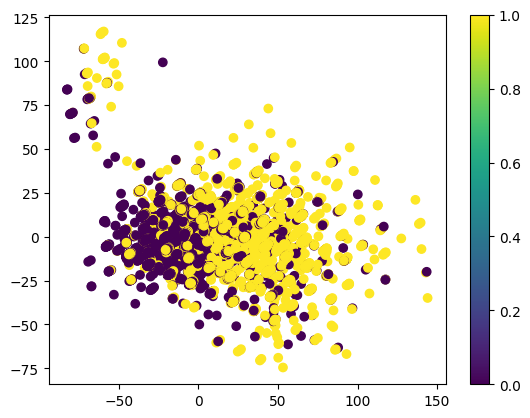

In [26]:
model = PCA(n_components=2)
model.fit(X)
x_pca = model.transform(X)
plt.scatter(x_pca[:,0], x_pca[:,1], c=Y)
plt.colorbar()

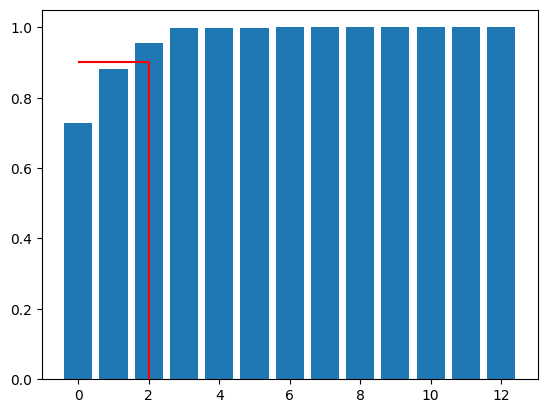

In [27]:
n_dims = X.shape[1]
model = PCA(n_components=n_dims)
model.fit(X)

variances = model.explained_variance_ratio_

meilleur_dims = np.argmax(np.cumsum(variances) > 0.90)


plt.bar(range(n_dims), np.cumsum(variances))
plt.hlines(0.90, 0, meilleur_dims, colors='r')
plt.vlines(meilleur_dims, 0, 0.90, colors='r')


In [28]:
print(make_regression(X))

Accuracy : 0.7152
Matrice de confusion :
[[5602 1299]
 [2607 4205]]
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      6901
           1       0.76      0.62      0.68      6812

    accuracy                           0.72     13713
   macro avg       0.72      0.71      0.71     13713
weighted avg       0.72      0.72      0.71     13713



/home/antoine/Desktop/plateforme/cardio-vasc-risks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.decomposition import PCA

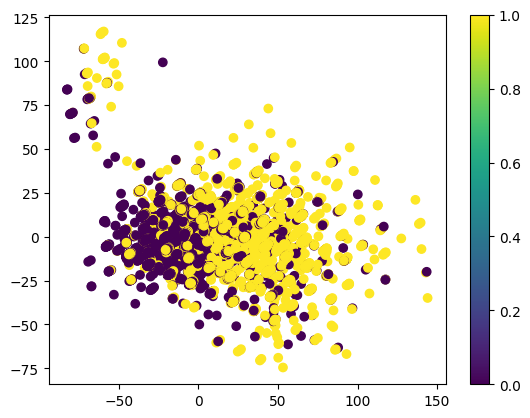

In [30]:
model = PCA(n_components=2)
model.fit(X)
x_pca = model.transform(X)
plt.scatter(x_pca[:,0], x_pca[:,1], c=Y)
plt.colorbar()

## Quatrième démarche

In [31]:
df = pd.read_csv("cardio_new_features.csv")

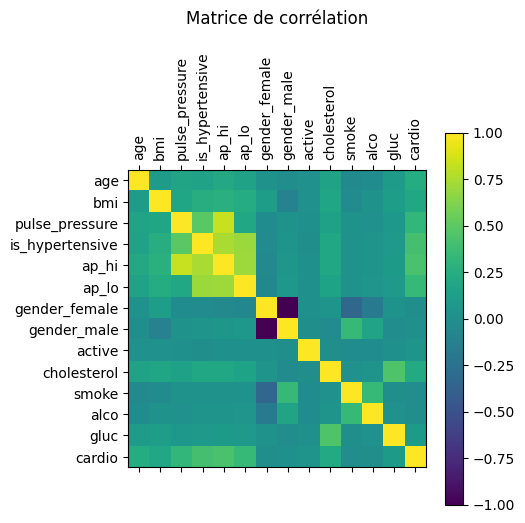

In [32]:
corr = df.corr(numeric_only=True)
plt.matshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Matrice de corrélation", pad=20)
plt.show()

In [33]:
int_corr = df.select_dtypes(include=['number']).corr()
int_corr[((int_corr <= -0.2) | (int_corr >= 0.2))]

,age,bmi,pulse_pressure,is_hypertensive,ap_hi,ap_lo,gender_female,gender_male,active,cholesterol,smoke,alco,gluc,cardio
age,1.000000,NaN,NaN,NaN,0.208667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.239558
bmi,NaN,1.000000,NaN,0.242927,0.268432,0.240899,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pulse_pressure,NaN,NaN,1.000000,0.484772,0.828222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.323470
is_hypertensive,NaN,0.242927,0.484772,1.000000,0.748175,0.698739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.412015
ap_hi,0.208667,0.268432,0.828222,0.748175,1.000000,0.706134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.425725
ap_lo,NaN,0.240899,NaN,0.698739,0.706134,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337419
gender_female,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN,-0.338835,NaN,NaN,NaN
gender_male,NaN,NaN,NaN,NaN,NaN,NaN,-1.000000,1.000000,NaN,NaN,0.338835,NaN,NaN,NaN
active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
cholesterol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,0.451025,0.221468


Nous pouvons voir que les corrélations directe de cardio est expliqué par : 
- pulse_pressure
- is_hipertensive
- ap_hi
- ap_lo

La construction d'un model utilisant ces paramètres est donc une piste.

/tmp/ipykernel_137393/268460743.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


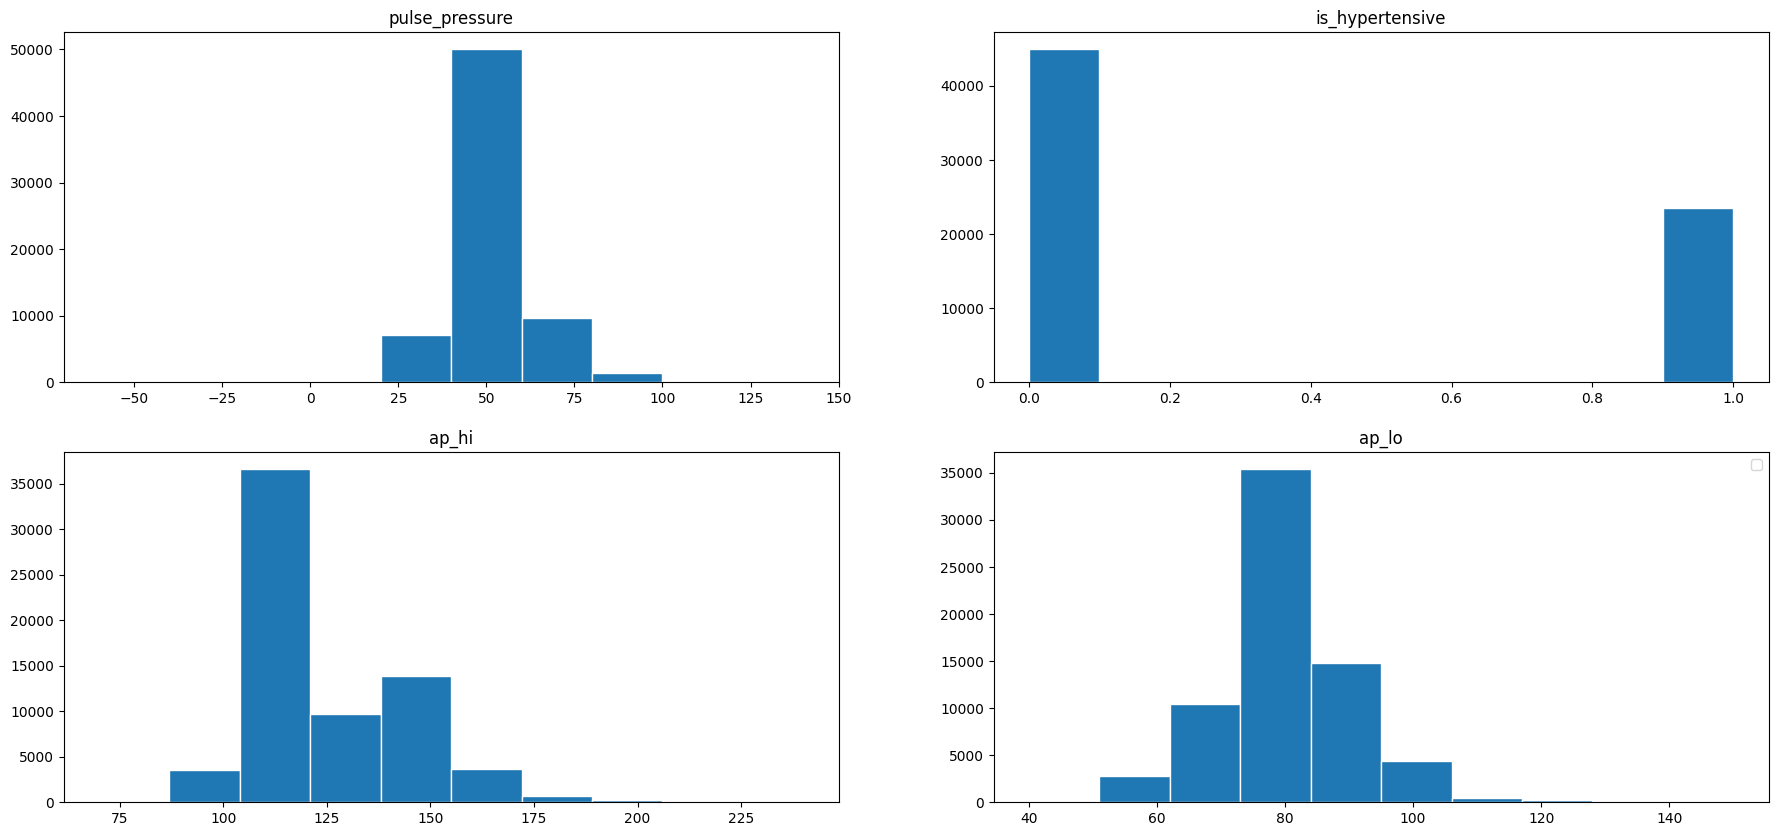

In [34]:
plt.figure(figsize=(22, 10))
cols = ['pulse_pressure', 'is_hypertensive', 'ap_hi', 'ap_lo']
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)  
    plt.hist(df[col], bins=10, edgecolor='white')
    plt.title(col)
plt.legend()
plt.show()

In [44]:
X = df[['pulse_pressure', 'is_hypertensive', 'ap_hi', 'ap_lo', 'bmi', 'age',"gluc","smoke","alco","active"]]
Y = df['cardio']
X.shape, Y.shape

KeyError: "['pulse_pressure', 'is_hypertensive', 'bmi'] not in index"

In [36]:
print(make_regression(X))

Accuracy : 0.7161
Matrice de confusion :
[[5626 1275]
 [2618 4194]]
              precision    recall  f1-score   support

           0       0.68      0.82      0.74      6901
           1       0.77      0.62      0.68      6812

    accuracy                           0.72     13713
   macro avg       0.72      0.72      0.71     13713
weighted avg       0.72      0.72      0.71     13713



/home/antoine/Desktop/plateforme/cardio-vasc-risks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Nous pouvons voir que ce model à une bonne précision concernant les trues positifs par rapport aux falses négatifs. Cependant, il n'arrive pas à prédire les valeurs négatives (true or false).

J'en conclu qu'il faut inclure des features qui permettraient d'aiguiller le model concernant les prédictions négatives.

In [45]:
df = pd.read_csv("cardio_train_clean.csv")
df['age'] = df['age'] / 360

X = df[["age_year", "gender","height","weight","ap_hi","ap_lo","cholesterol","gluc","smoke","alco","active"]] 
y = df["cardio"] 

KeyError: "['age_year'] not in index"

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Pipeline avec un scaler et un modèle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

# Grille des hyperparamètres à tester
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],               # Régularisation
    'logreg__penalty': ['l1', 'l2'],                   # Types de pénalité
    'logreg__solver': ['liblinear', 'saga']            # Solvers compatibles
}

# Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X, Y.ravel())  # y.ravel() pour enlever les dimensions inutiles

# Résultats
print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleure précision :", grid_search.best_score_)

# Évaluation sur les données
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X)

print(classification_report(Y, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


/tmp/ipykernel_137393/2233148614.py:22: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  grid_search.fit(X, Y.ravel())  # y.ravel() pour enlever les dimensions inutiles


Meilleurs hyperparamètres : {'logreg__C': 0.1, 'logreg__penalty': 'l1', 'logreg__solver': 'saga'}
Meilleure précision : 0.7270937203588722
              precision    recall  f1-score   support

           0       0.71      0.79      0.74     34628
           1       0.75      0.67      0.71     33934

    accuracy                           0.73     68562
   macro avg       0.73      0.73      0.73     68562
weighted avg       0.73      0.73      0.73     68562



## Meilleur model : sans preprocessing

In [48]:
df = pd.read_csv("cardio_train_clean.csv")
df["age_year"] = df["age"] / 365

In [47]:
X = df[["age_year", "gender","height","weight","ap_hi","ap_lo","cholesterol","gluc","smoke","alco","active"]] 
y = df["cardio"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

y_pred = model.predict(X_test)

# Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matrice de confusion:\n", confusion_matrix(y_test, y_pred))
print("Rapport de classification:\n", classification_report(y_test, y_pred))


Accuracy: 0.7263180923211551
Matrice de confusion:
 [[5393 1539]
 [2214 4567]]
Rapport de classification:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74      6932
           1       0.75      0.67      0.71      6781

    accuracy                           0.73     13713
   macro avg       0.73      0.73      0.73     13713
weighted avg       0.73      0.73      0.73     13713



Ce model simpliste reste le plus performant au niveu de la plus part des metrics. Le recall n'est pas très bon pour la classe 1 mais tout les autres restent plutot performantes. Nous allons donc répondre à la question 